# Deep Neural Network for CAT Image Binary Classification

In [13]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from utils import*
from PIL import Image


### Load Data Set

In [2]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_data()

y = 0. It's a non-cat picture.


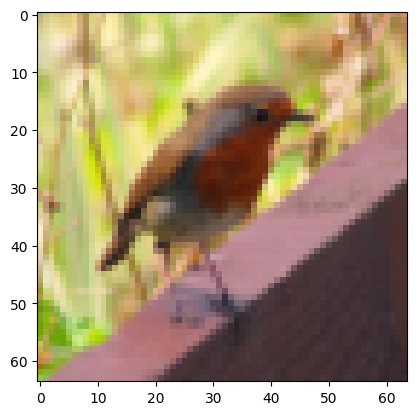

In [3]:
# Example of a picture
index = 10
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [4]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [5]:
# Reshape the training and test examples 
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


### Deep NN Training


In [6]:
### CONSTANTS ###
layers_dims = [12288, 20, 7, 5, 1] #  4-layer model

In [7]:
def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
    Implements a L-layer neural network: [LINEAR->RELU]*(L-1)->LINEAR->SIGMOID.
    
    Arguments:
    X -- input data, of shape (n_x, number of examples)
    Y -- true "label" vector (containing 1 if cat, 0 if non-cat), of shape (1, number of examples)
    layers_dims -- list containing the input size and each layer size, of length (number of layers + 1).
    learning_rate -- learning rate of the gradient descent update rule
    num_iterations -- number of iterations of the optimization loop
    print_cost -- if True, it prints the cost every 100 steps
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to predict.
    """


    np.random.seed(1)
    costs = []                         # keep track of cost

    # Parameters initialization.
    parameters = initialize_parameters(layers_dims)

    # Loop (gradient descent)

    for i in range(num_iterations):

        #forward propogation

        AL, caches = L_model_forward(X,parameters)

        #cost
        cost = compute_cost(AL,Y)


        #backward propogation
        grads = L_model_backward(AL, Y, caches)

        parameters = update_parameters(parameters, grads, learning_rate)

        # Print the cost every 100 iterations and for the last iteration
        if print_cost and (i % 100 == 0 or i == num_iterations - 1):
            print("Cost after iteration {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0:
            costs.append(cost)


    return parameters, costs
         


In [8]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Cost after iteration 0: 0.8116017481136114
Cost after iteration 100: 0.6676695646220321
Cost after iteration 200: 0.6339824668918083
Cost after iteration 300: 0.6057467650054879
Cost after iteration 400: 0.5629711332996643
Cost after iteration 500: 0.41594126531630216
Cost after iteration 600: 0.3204714324288978
Cost after iteration 700: 0.2324734795290719
Cost after iteration 800: 0.14847577500848455
Cost after iteration 900: 0.08750257977951138
Cost after iteration 1000: 0.05738770594106722
Cost after iteration 1100: 0.03993652491220218
Cost after iteration 1200: 0.030270549594624805
Cost after iteration 1300: 0.024070231198004256
Cost after iteration 1400: 0.019656556059355217
Cost after iteration 1500: 0.016491698536305232
Cost after iteration 1600: 0.014169402307804961
Cost after iteration 1700: 0.012192418435785689
Cost after iteration 1800: 0.010697445643829247
Cost after iteration 1900: 0.009464245952082272
Cost after iteration 2000: 0.0084878494549911
Cost after iteration 2100

In [9]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 0.9999999999999998


In [10]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 0.8


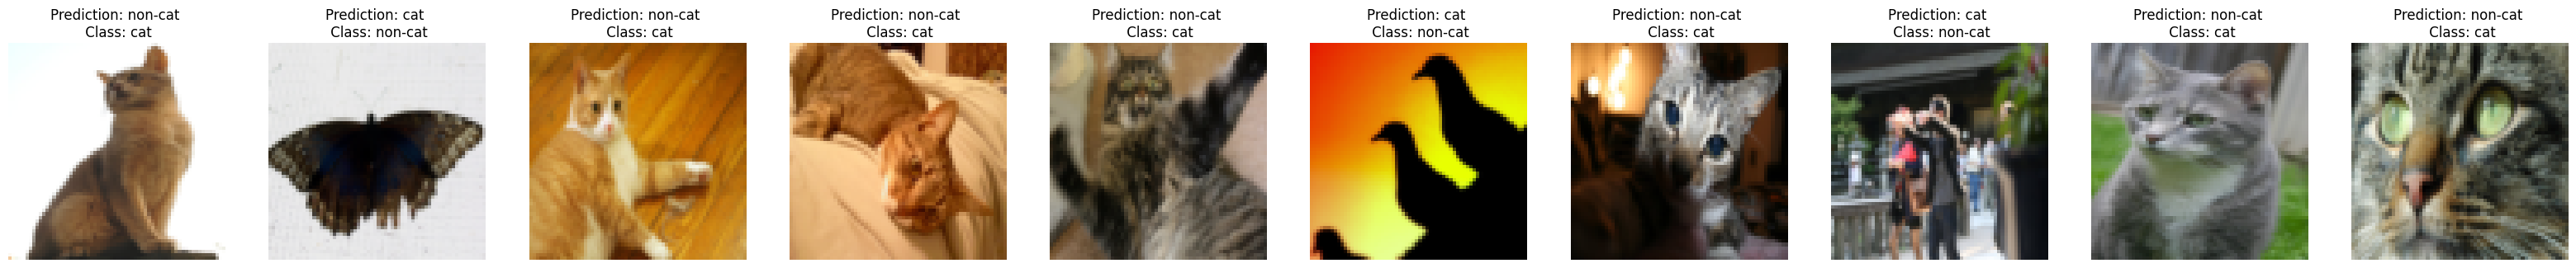

In [11]:
print_mislabeled_images(classes, test_x, test_y, pred_test)

Accuracy: 1.0
y = 0.0, your L-layer model predicts a "non-cat" picture.


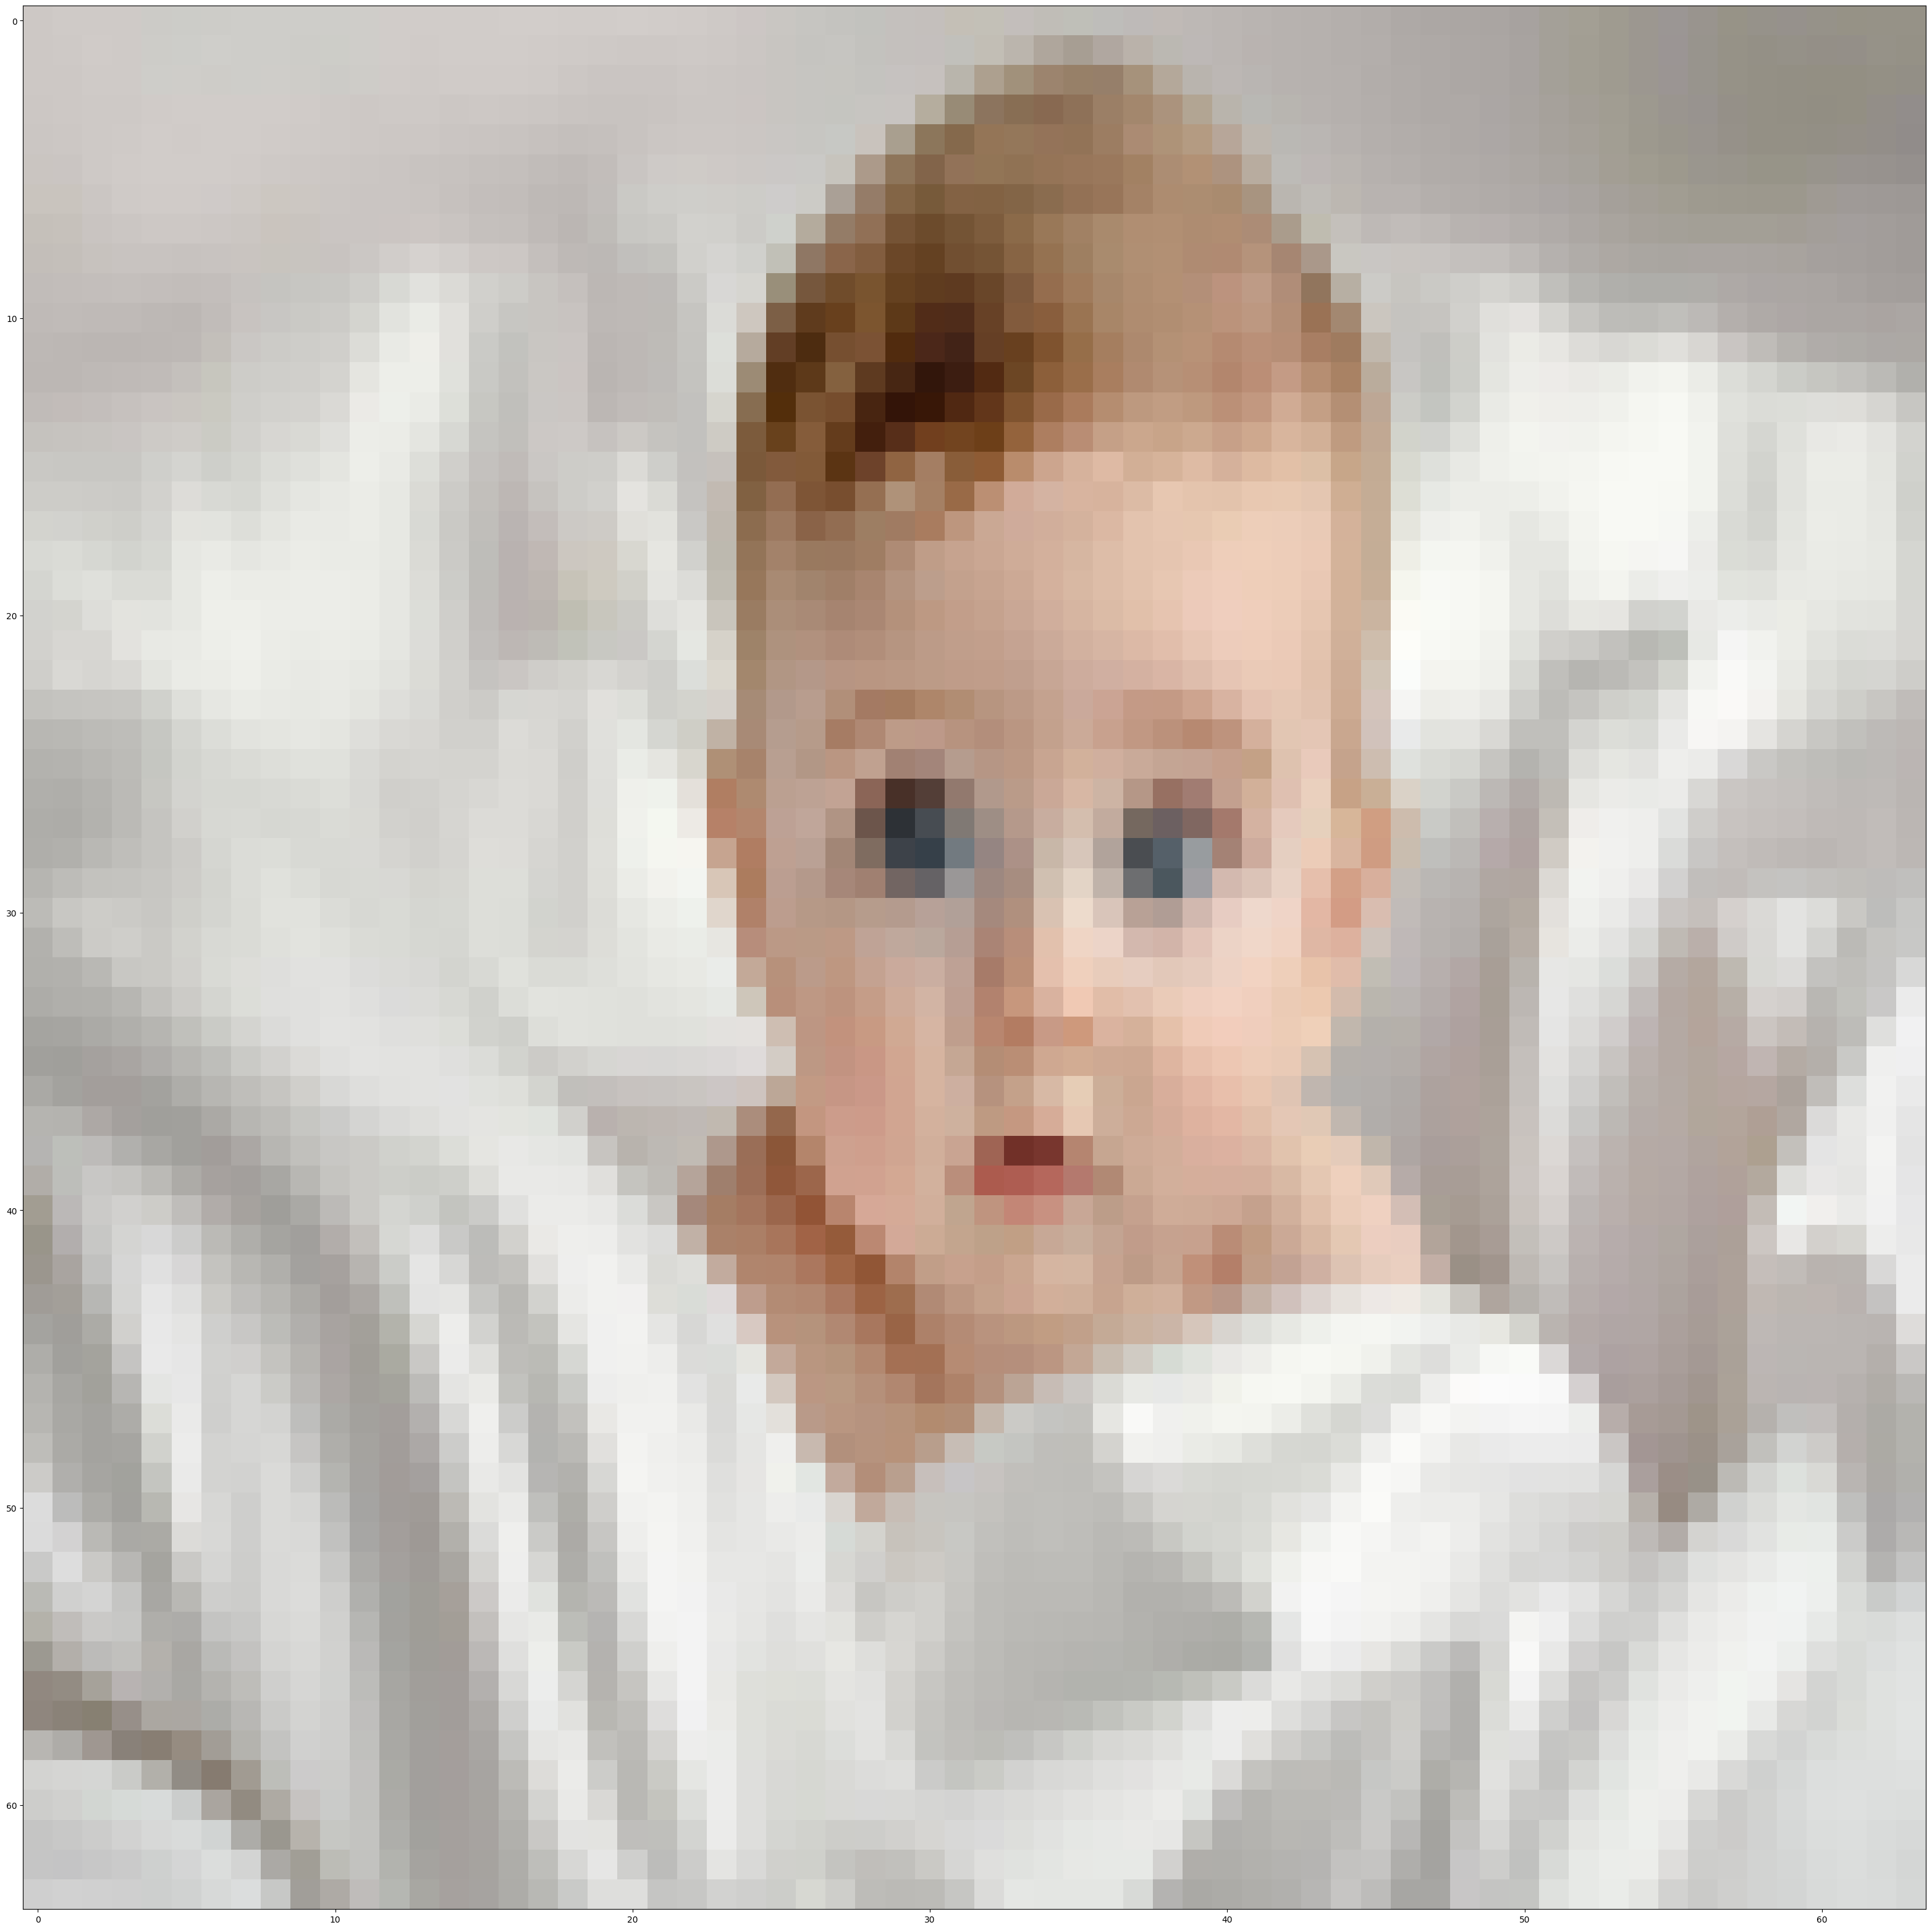

In [19]:

my_image = "baby.jpg" # change this to the name of your image file 
my_label_y = [0] # the true class of your image (1 -> cat, 0 -> non-cat)


fname = "images/" + my_image
image = np.array(Image.open(fname).resize((num_px, num_px)))
plt.imshow(image)
image = image / 255.
image = image.reshape((1, num_px * num_px * 3)).T

my_predicted_image = predict(image, my_label_y, parameters)


print ("y = " + str(np.squeeze(my_predicted_image)) + ", your L-layer model predicts a \"" + classes[int(np.squeeze(my_predicted_image)),].decode("utf-8") +  "\" picture.")